# Clustering analysis

Inspect, transform, scale and cluster the saved daily dataset.

Run from the repository folder with the `.venv` kernel. This notebook uses local data only; run `01_daily_macro_dataset.ipynb` first if the CSV is missing.


In [ ]:
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


## Load and preview

Load the version that preserves all equity trading dates and missing macro observations. No filling or scaling is applied.


In [ ]:
df = pd.read_csv("data/daily_macro_levels.csv", index_col="date", parse_dates=["date"])
df.head()


,sp500,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread
date,,,,,,,,
2011-10-05,1144.030029,1.80,0.12,1.67,3.36,37.81,38.31,-0.50
2011-10-06,1164.969971,1.88,0.13,1.72,3.34,36.27,37.04,-0.77
2011-10-07,1155.459961,1.94,0.16,1.80,3.32,36.20,37.31,-1.11
2011-10-10,1194.890015,NaN,NaN,NaN,NaN,33.02,34.79,-1.77
2011-10-11,1195.540039,1.95,0.23,1.86,3.32,32.86,34.06,-1.20


In [ ]:
df.isnull().sum()

sp500               0
breakeven_10y      28
real_yield_10y     29
slope_10y_2y       28
baa_10y_spread     31
vix                 0
vix3m               0
vix_term_spread     0
dtype: int64

In [ ]:
df_complete = df.dropna()
df_complete.isnull().sum()

sp500              0
breakeven_10y      0
real_yield_10y     0
slope_10y_2y       0
baa_10y_spread     0
vix                0
vix3m              0
vix_term_spread    0
dtype: int64

## Daily levels: compact mosaic

One time-series panel per variable, with a shared date axis and separate vertical scales. Use the complete observations in `df_complete`. The term spread is **VIX − VIX3M**.

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

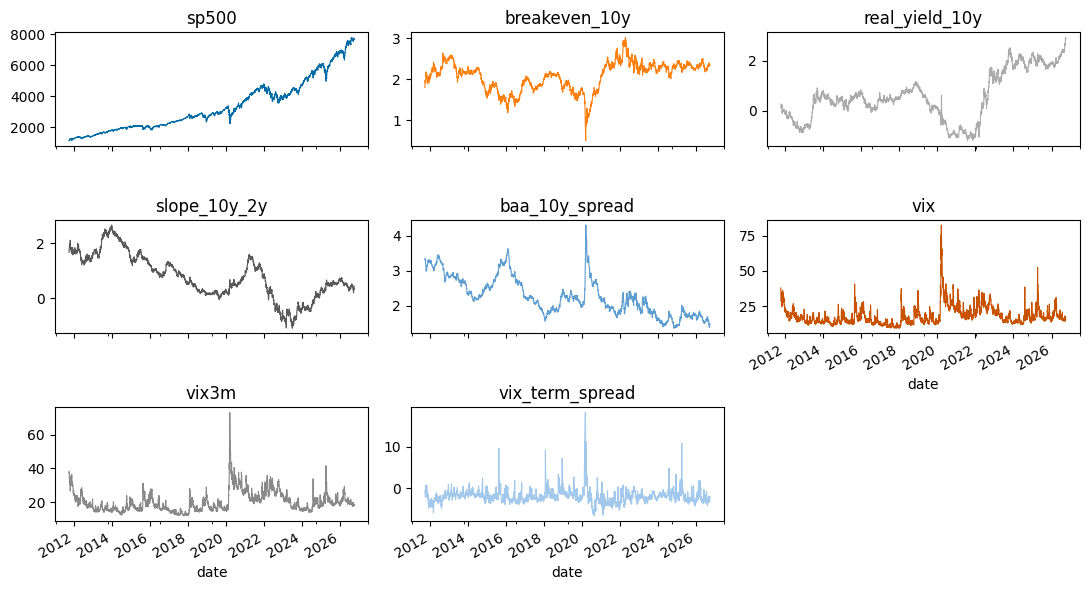

In [ ]:
with plt.style.context("tableau-colorblind10"):
    axes = df_complete.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                   sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_complete.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## S&P 500 log returns

Chapter 3.2.1 uses previously calculated equity log returns. Here we calculate them from our S&P 500 levels; the other variables remain in levels. Calculate returns on `df` before dropping missing rows to preserve the equity trading-day intervals.


In [ ]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()


In [ ]:
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## Clustering

To be developed next: choose features and transformations, then fit and evaluate clusters.


In [ ]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()


In [ ]:
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(3, 3), figsize=(11, 6),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    plt.tight_layout()
    plt.show()

## Conventional partitioning

This plot shows a potential partitioning of the market variables with a 25-75 percentile low-mid-high logic. 

This can offer intuitive interpretability certain cases. A major risk is that the joint occurrance of certian states get too low, sparse. In this current configuration there are 3^8 = 6,561 joint states. It is almost impossible to understand all those scenarios. Instead, I propose unsupervised technique to compress the states down to smaller number with distinguishable profiles. 

In [ ]:
with plt.style.context("tableau-colorblind10"):
    fig, axes = plt.subplots(3, 3, figsize=(11, 6), sharex=True, layout="constrained")
    for ax, column in zip(axes.flat, df_transformed.columns):
        series = df_transformed[column]
        q25, q75 = series.quantile([0.25, 0.75])
        partitions = {
            "Low: ≤25th percentile": series <= q25,
            "Middle: 25th–75th": (series > q25) & (series <= q75),
            "High: >75th percentile": series > q75,
        }
        for label, mask in partitions.items():
            ax.scatter(series.index[mask], series[mask], s=3, label=label)
        for threshold in [q25, q75]:
            ax.axhline(threshold, color="grey", linestyle="--", linewidth=0.7)
        ax.set_title(column)

    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    fig.legend(*axes.flat[0].get_legend_handles_labels(),
               loc="outside lower center", ncol=3, markerscale=3)
    plt.show()

## EDA

In [ ]:
df_transformed.describe(include = 'all').T

In [ ]:
from sklearn.preprocessing import StandardScaler
# Scaling the data before clustering
scaler = StandardScaler()
subset = df_transformed.copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
subset_scaled_df = pd.DataFrame(
    subset_scaled, columns=subset.columns, index=subset.index
)

In [ ]:
subset_scaled_df.head()

In [ ]:
# Importing PCA
from sklearn.decomposition import PCA

# Defining the number of principal components to generate
n = subset.shape[1]                                                 # Storing the number of variables in the data

pca = PCA(n_components = n, random_state = 1)                       # Storing PCA function with n components

data_pca = pd.DataFrame(pca.fit_transform(subset_scaled_df ))       # Applying PCA on scaled data

# The percentage of variance explained by each principal component is stored
exp_var = (pca.explained_variance_ratio_)
exp_var

## t-SNE visualization

Embed the standardized features in two dimensions to inspect local neighborhoods before K-means. Color indicates observation date. t-SNE is a visualization: distances between distant groups and their relative sizes should not be interpreted as regime separation. K-means below continues to use `data_pca`.


In [ ]:
from sklearn.manifold import TSNE

# Fixed seed and PCA initialization make repeated runs reproducible.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=1,
)
tsne_df = pd.DataFrame(
    tsne.fit_transform(subset_scaled_df),
    columns=["TSNE1", "TSNE2"],
    index=subset_scaled_df.index,
)

with plt.style.context("tableau-colorblind10"):
    fig, ax = plt.subplots(figsize=(8, 6))
    points = ax.scatter(
        tsne_df["TSNE1"], tsne_df["TSNE2"],
        c=mdates.date2num(tsne_df.index.to_pydatetime()),
        cmap="viridis", s=8, alpha=0.7, linewidths=0,
    )
    colorbar = fig.colorbar(points, ax=ax, label="Observation date")
    colorbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
           title="t-SNE of standardized market variables")
    plt.tight_layout()
    plt.show()


In [ ]:
k_means_df = data_pca.copy()

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters = k, random_state = 1, n_init = "auto")
    model.fit(data_pca)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis = 1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize = 20)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 1, n_init = "auto")
kmeans.fit(k_means_df)

In [ ]:
# Creating a copy of the original data
df1 = df_transformed.copy()

# Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [ ]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only = True)

In [ ]:
df1.head()

In [ ]:
# Creating the "count_in_each_segment" feature in K-Means cluster profile

km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["sp500_log_return"].count().values
)

In [ ]:
km_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

In [ ]:
plt.style.use("tableau-colorblind10")
plt.figure(figsize=(7, 5))
for cluster in np.unique(kmeans.labels_):
    mask = kmeans.labels_ == cluster
    plt.scatter(data_pca.iloc[mask, 0], data_pca.iloc[mask, 1],
                s=10, alpha=0.6, label=f"Cluster {cluster}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)

performance = []
for k in range(2, 11):
    candidate = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(data_pca)
    labels = candidate.labels_
    performance.append([
        k, candidate.inertia_, silhouette_score(data_pca, labels),
        calinski_harabasz_score(data_pca, labels),
        davies_bouldin_score(data_pca, labels),
    ])

performance_df = pd.DataFrame(performance, columns=[
    "k", "Inertia", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin",
]).set_index("k")
performance_df.round(3)

In [ ]:
axes = performance_df.plot(subplots=True, layout=(2, 2), figsize=(10, 6),
                           sharex=True, legend=False, marker="o")
for ax, metric in zip(axes.flat, performance_df.columns):
    ax.set_title(metric)
    ax.axvline(kmeans.n_clusters, color="grey", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(10, 4))
dendrogram(ward_linkage, truncate_mode="lastp", p=25, show_leaf_counts=True)
plt.title("Ward hierarchy: 25 terminal groups")
plt.xlabel("Collapsed groups; counts in parentheses")
plt.ylabel("Ward linkage distance")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import pdist

pairwise_distances = pdist(data_pca, metric="euclidean")
ward_linkage = linkage(pairwise_distances, method="ward")
cophenetic_correlation, _ = cophenet(ward_linkage, pairwise_distances)
cophenetic_correlation